In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract

from pathlib import Path

folder = Path('./Placas/')
%matplotlib inline

In [3]:
plates_cascade = cv2.CascadeClassifier( cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml' )

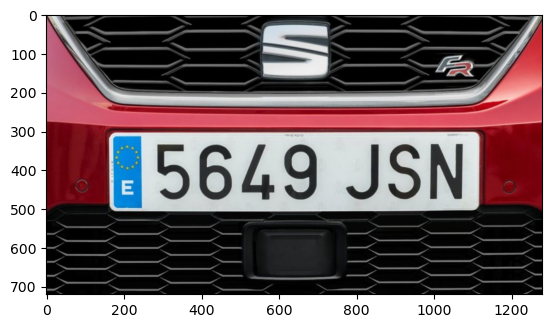

In [4]:
img = cv2.imread( 'Placas/placa2.jpg' )
img = cv2.cvtColor( img, cv2.COLOR_BGR2RGB )
plt.imshow( img, cmap='Accent' )
plt.show()

In [6]:
# Detectando la Placa

placas = plates_cascade.detectMultiScale(img, 1.0005, 4)
print(placas)

error: Unknown C++ exception from OpenCV code

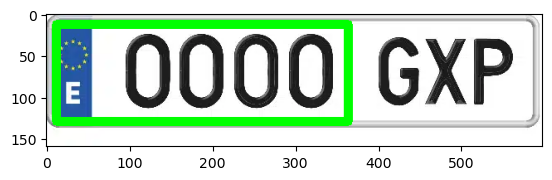

In [ ]:
img_copy = np.copy( img )
for ( x, y, w, h ) in placas:
    cv2.rectangle( img_copy, ( x, y ), ( x + w, y + h), ( 0, 255, 0 ), 10 )
    
plt.imshow( img_copy, cmap='Accent' )
plt.show()

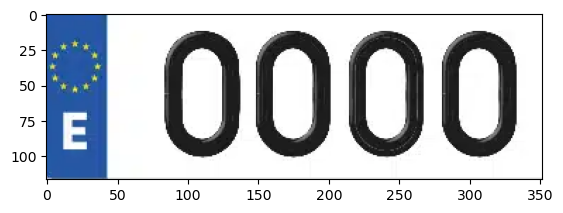

In [ ]:
placaRGB = img[ y : y + h, x : x + w, : ]
plt.imshow( placaRGB, cmap='Accent' )
plt.show()

In [ ]:
textoRGB = pytesseract.image_to_string(placaRGB)
print(textoRGB)

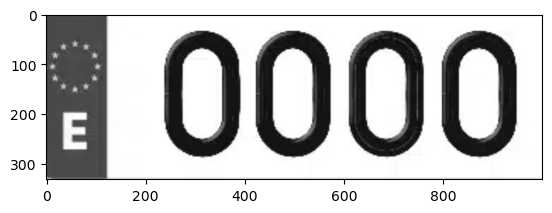

In [ ]:
placaGray = cv2.cvtColor( placaRGB, cv2.COLOR_RGB2GRAY)
h, w = placaGray.shape[:2]
img = cv2.resize(placaGray, (1000, int(1000*h/w)))
plt.imshow( img, cmap='gray' )
plt.show()

In [ ]:
textoGray = pytesseract.image_to_string( placaGray )
print(textoGray)

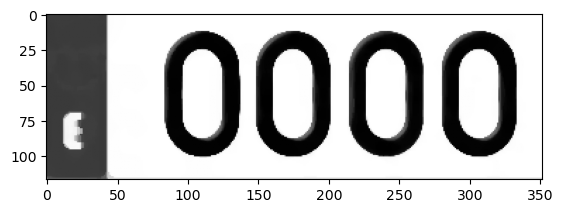

In [ ]:
placaFiltrada = cv2.medianBlur( placaGray, 9)
plt.imshow( placaFiltrada, cmap='gray' )
plt.show()

In [ ]:
textoFiltro = pytesseract.image_to_string( placaFiltrada )
print( textoFiltro )

In [ ]:
ret, placaBin = cv2.threshold( placaFiltrada, 99, 3, cv2.THRESH_BINARY )
plt.imshow( placaBin, cmap='gray' )
plt.show()

textoBin = pytesseract.image_to_string( placaBin )
print( textoBin )

NameError: name 'cv2' is not defined